# Linear Probing — Face-Aware MAE vs Baselines

## Cell 1 — Install & Imports

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  

# Uncomment below ONLY if AcceleratorError persists after restricting GPU:
# !pip install torch==2.5.1 torchvision==0.20.1 --quiet

!pip install timm --quiet

import os, json, time, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import balanced_accuracy_score
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision.transforms as T
from torchvision.datasets import CelebA

import timm
from timm.models.vision_transformer import VisionTransformer

warnings.filterwarnings('ignore')
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}  : {torch.cuda.get_device_name(i)}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device   : {DEVICE}")

PyTorch  : 2.10.0+cu128
CUDA     : True
  GPU 0  : Tesla T4
Device   : cuda


## Cell 2 — Config 

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# DATA
# ─────────────────────────────────────────────────────────────────────────────
# Kaggle: Add CelebA dataset → /kaggle/input/celeba-dataset/
# Cấu trúc cần có:
#   /kaggle/input/celeba-dataset/img_align_celeba/   (ảnh)
#   /kaggle/input/celeba-dataset/list_attr_celeba.csv
#   /kaggle/input/celeba-dataset/list_eval_partition.csv
CELEBA_ROOT = "/kaggle/input/datasets/jessicali9530/celeba-dataset"

# ─────────────────────────────────────────────────────────────────────────────
# CHECKPOINTS
# ─────────────────────────────────────────────────────────────────────────────
# Điền đường dẫn tới file results_incremental.json (nếu có) để chạy tiếp.
# Ví dụ: RESUME_FROM_JSON_PATH = '/kaggle/input/my-backup/results_incremental.json'
# Để chuỗi rỗng "" nếu muốn chạy lại từ đầu.
RESUME_FROM_JSON_PATH = ""

# ─────────────────────────────────────────────────────────────────────────────
# Key   : tên strategy (dùng làm label trong bảng kết quả)
# Value : dict seed -> đường dẫn tới checkpoint .pth
#
# Checkpoint phải chứa key 'encoder' hoặc 'model' với state_dict của ViT encoder.
# Nếu save toàn bộ MAE model thì xem Cell 4 để chỉnh load logic.
CKPT_PATHS = {
    # "Random": {
    #     42:   "/kaggle/input/mae-checkpoints/random_seed42.pth",
    #     123:  "/kaggle/input/mae-checkpoints/random_seed123.pth",
    #     2026: "/kaggle/input/mae-checkpoints/random_seed2026.pth",
    # },
    # "Block-wise": {
    # 42:   "/kaggle/input/mae-checkpoints/blockwise_seed42.pth",
    # 123:  "/kaggle/input/mae-checkpoints/blockwise_seed123.pth",
    # 2026: "/kaggle/input/mae-checkpoints/blockwise_seed2026.pth",
    # },
    "Face-Aware": {
    42:   "/kaggle/input/datasets/doandangkhoa/mae-checkpoints/faceaware_best.pth",
    123:  "/kaggle/input/datasets/doandangkhoa/mae-checkpoints/faceaware_best(123).pth",
    2026: "/kaggle/input/datasets/doandangkhoa/mae-checkpoints/faceaware_best(2026).pth",
    },
}
SEEDS = [42, 123, 2026]

# ─────────────────────────────────────────────────────────────────────────────
# ATTRIBUTES
# list_attr_celeba.csv có 40 attributes theo thứ tự:
# Index 0-based. Xem full list: https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html
# ─────────────────────────────────────────────────────────────────────────────
ATTR_CONFIG = {
    #  Tên hiển thị    : index trong tensor attrs (0-based)
    "Eyeglasses" : 15,   # periocular-dependent → trực tiếp trong identity triangle
    "Smiling"    : 31,   # oral-region-dependent
    "Male"       : 20,   # holistic facial structure
}

# ─────────────────────────────────────────────────────────────────────────────
# ENCODER ARCHITECTURE — phải khớp với lúc pretrain
# ─────────────────────────────────────────────────────────────────────────────
ENCODER_CFG = dict(
    img_size    = 224,
    patch_size  = 16,
    embed_dim   = 384,   # D_e
    depth       = 6,
    num_heads   = 6,
    mlp_ratio   = 4.0,
    num_classes = 0,     # không có classification head
    global_pool = '',    # trả về toàn bộ token sequence (B, N, D)
)

# ─────────────────────────────────────────────────────────────────────────────
# LINEAR PROBE TRAINING
# ─────────────────────────────────────────────────────────────────────────────
PROBE_CFG = dict(
    epochs     = 50,
    batch_size = 256,
    lr         = 1e-3,
    weight_decay = 0.0,
    num_workers  = 2,
)

# ─────────────────────────────────────────────────────────────────────────────
# OUTPUT
# ─────────────────────────────────────────────────────────────────────────────
OUTPUT_DIR = Path("/kaggle/working/linear_probe_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Config loaded ✓")
print(f"Strategies : {list(CKPT_PATHS.keys())}")
print(f"Seeds      : {SEEDS}")
print(f"Attributes : {list(ATTR_CONFIG.keys())}")
print(f"Total runs : {len(CKPT_PATHS) * len(SEEDS) * len(ATTR_CONFIG)}")

Config loaded ✓
Strategies : ['Face-Aware']
Seeds      : [42, 123, 2026]
Attributes : ['Eyeglasses', 'Smiling', 'Male']
Total runs : 9


## Cell 3 — Dataset & DataLoader

In [3]:
# ─── Transform giống hệt lúc pretrain ────────────────────────────────────────
# CelebA mean/std chuẩn (ImageNet-style, thường dùng cho MAE)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_transform = T.Compose([
    # MAE linear-probe protocol: RandomResizedCrop (not CenterCrop)
    T.RandomResizedCrop(224, scale=(0.2, 1.0)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ─── Load CelebA ─────────────────────────────────────────────────────────────
import os
import pandas as pd
from PIL import Image

class CustomCelebA(Dataset):
    """
    Custom Dataset để đọc file .csv từ dataset của jessicali9530 trên Kaggle.
    (PyTorch CelebA mặc định chỉ đọc được file .txt)
    """
    def __init__(self, root, split='train', target_type='attr', transform=None, download=False):
        self.root = root
        self.transform = transform
        
        attr_path = os.path.join(root, 'list_attr_celeba.csv')
        part_path = os.path.join(root, 'list_eval_partition.csv')
        
        # Xử lý path ảnh (đôi khi bị lồng folder img_align_celeba/img_align_celeba)
        self.img_dir = os.path.join(root, 'img_align_celeba', 'img_align_celeba')
        if not os.path.exists(self.img_dir):
            self.img_dir = os.path.join(root, 'img_align_celeba')
            
        if not os.path.exists(attr_path) or not os.path.exists(part_path):
            raise FileNotFoundError(f"Không tìm thấy CSV files tại {root}")
            
        attr_df = pd.read_csv(attr_path)
        part_df = pd.read_csv(part_path)
        df = pd.merge(attr_df, part_df, on='image_id')
        
        split_map = {'train': 0, 'valid': 1, 'test': 2}
        self.df = df[df['partition'] == split_map[split]].reset_index(drop=True)
        
        self.filenames = self.df['image_id'].values
        attrs = self.df.iloc[:, 1:41].values
        attrs = (attrs + 1) // 2  # Chuyển -1 thành 0 để giống chuẩn PyTorch
        self.attrs = torch.tensor(attrs, dtype=torch.long)
        
    def __len__(self):
        return len(self.filenames)
        
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.filenames[idx])
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.attrs[idx]

# torchvision CelebA: split='train' → partition 0, 'valid' → partition 1
# target_type='attr' → trả về tensor shape (40,) với giá trị 0/1
print("Loading CelebA train split...")
train_dataset = CustomCelebA(
    root        = CELEBA_ROOT,
    split       = 'train',
    target_type = 'attr',
    transform   = train_transform,
    download    = False,
)

print("Loading CelebA val split...")
val_dataset = CustomCelebA(
    root        = CELEBA_ROOT,
    split       = 'valid',
    target_type = 'attr',
    transform   = val_transform,
    download    = False,
)

print(f"Train size : {len(train_dataset):,}")
print(f"Val size   : {len(val_dataset):,}")

# ─── Kiểm tra class balance cho 3 attributes ─────────────────────────────────
print("\nClass balance check:")
all_train_attrs = torch.stack([train_dataset[i][1] for i in range(min(5000, len(train_dataset)))])
for attr_name, attr_idx in ATTR_CONFIG.items():
    pos_rate = all_train_attrs[:, attr_idx].float().mean().item()
    print(f"  {attr_name:12s} (idx={attr_idx}): {pos_rate*100:.1f}% positive")

Loading CelebA train split...
Loading CelebA val split...
Train size : 162,770
Val size   : 19,867

Class balance check:
  Eyeglasses   (idx=15): 6.3% positive
  Smiling      (idx=31): 48.1% positive
  Male         (idx=20): 41.7% positive


## Cell 4 — Encoder & Linear Probe Model

In [4]:
def build_encoder():
    """
    Tạo ViT-Small encoder với config khớp lúc pretrain.
    Dùng timm để đảm bảo đúng architecture.
    """
    model = timm.create_model(
        'vit_small_patch16_224',
        pretrained   = False,
        num_classes  = 0,        # remove classification head
        global_pool  = '',       # trả về full sequence (B, N+1, D)
        img_size     = ENCODER_CFG['img_size'],
        patch_size   = ENCODER_CFG['patch_size'],
        embed_dim    = ENCODER_CFG['embed_dim'],
        depth        = ENCODER_CFG['depth'],
        num_heads    = ENCODER_CFG['num_heads'],
        mlp_ratio    = ENCODER_CFG['mlp_ratio'],
        class_token  = False,       # MAE encoder không dùng CLS token
    )
    return model


def load_encoder_from_checkpoint(ckpt_path: str) -> nn.Module:
    """
    Load encoder weights từ MAE checkpoint.
    
    Hỗ trợ các format checkpoint phổ biến:
      1. {'encoder': state_dict}          ← cấu trúc lý tưởng
      2. {'model': state_dict}            ← save toàn bộ MAE
      3. state_dict trực tiếp             ← chỉ save encoder
    
    Nếu checkpoint của bạn có cấu trúc khác, chỉnh hàm này.
    """
    encoder = build_encoder()
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    
    # ── Tìm đúng state_dict ──────────────────────────────────────────────────
    if isinstance(ckpt, dict):
        if 'encoder' in ckpt:
            state_dict = ckpt['encoder']
        elif 'model' in ckpt:
            # Lọc chỉ lấy encoder keys (bỏ decoder.*) và strip DataParallel prefix
            raw = ckpt['model']
            state_dict = {}
            for k, v in raw.items():
                k_clean = k.replace('module.', '')
                if k_clean.startswith('encoder.'):
                    state_dict[k_clean.replace('encoder.', '')] = v
            
            if not state_dict:  # fallback: thử dùng toàn bộ (đã xóa module.)
                state_dict = {k.replace('module.', ''): v for k, v in raw.items()}
        elif 'state_dict' in ckpt:
            state_dict = ckpt['state_dict']
        else:
            state_dict = ckpt  # checkpoint là state_dict trực tiếp
    else:
        raise ValueError(f"Unexpected checkpoint format: {type(ckpt)}")
    
    # ── Load với strict=False để bỏ qua key không khớp ───────────────────────
    missing, unexpected = encoder.load_state_dict(state_dict, strict=False)
    if missing:
        print(f"  [WARN] Missing keys  : {missing[:3]}{'...' if len(missing)>3 else ''}")
    if unexpected:
        print(f"  [WARN] Unexpected    : {unexpected[:3]}{'...' if len(unexpected)>3 else ''}")
    
    return encoder


class LinearProbe(nn.Module):
    """
    Frozen encoder + trainable linear head.
    
    Feature extraction: mean pool toàn bộ token sequence
    (không dùng CLS token vì MAE ViT-Small thường không có CLS)
    """
    def __init__(self, encoder: nn.Module, embed_dim: int = 384):
        super().__init__()
        self.encoder    = encoder
        # MAE paper: BN (affine=False) normalizes frozen features before head
        self.head = nn.Sequential(
            nn.BatchNorm1d(embed_dim, affine=False, eps=1e-6),
            nn.Linear(embed_dim, 1),
        )
        
        # Đóng băng encoder
        for param in self.encoder.parameters():
            param.requires_grad = False
        self.encoder.eval()
    
    def get_features(self, x: torch.Tensor) -> torch.Tensor:
        """Extract pooled features — không tính gradient qua encoder."""
        with torch.no_grad():
            tokens = self.encoder(x)   # (B, N, D) hoặc (B, N+1, D)
            # MAE paper: skip CLS token (idx=0), mean pool patch tokens only
            # Không có CLS token (class_token=False) → mean pool tất cả patch tokens
            feat   = tokens.mean(dim=1)  # (B, D)
        return feat
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat = self.get_features(x)
        return self.head(feat).squeeze(1)  # (B,)
    
    def train(self, mode=True):
        """Override: encoder luôn ở eval mode dù LinearProbe đang train."""
        super().train(mode)
        self.encoder.eval()  # BẮT BUỘC
        return self


# ─── Quick smoke test ─────────────────────────────────────────────────────────
print("Smoke test encoder...")
_enc = build_encoder().to(DEVICE)
_x   = torch.randn(2, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    _out = _enc(_x)
print(f"  Input  : {tuple(_x.shape)}")
print(f"  Output : {tuple(_out.shape)}  ← expected (2, 197, 384) — CLS + 196 patches")

del _enc, _x, _out
print("Encoder OK ✓")


Smoke test encoder...
  Input  : (2, 3, 224, 224)
  Output : (2, 196, 384)  ← expected (2, 197, 384) — CLS + 196 patches
Encoder OK ✓


## Cell 5 — Train & Evaluate Functions

In [5]:
# =============================================================================
# Helper: Tính pos_weight cho class imbalance
# =============================================================================
def get_pos_weight(labels_tensor: torch.Tensor) -> torch.Tensor:
    """
    Tính pos_weight từ label tensor đã extract sẵn.
    pos_weight = n_negative / n_positive
    """
    n_pos = labels_tensor.sum().item()
    n_neg = len(labels_tensor) - n_pos
    weight = n_neg / max(n_pos, 1)
    return torch.tensor([weight])


# =============================================================================
# KEY OPTIMIZATION: Pre-extract frozen features ONCE per checkpoint
# Encoder is frozen → features never change across epochs → extract once!
# This reduces training from ~7.6h/run to ~10min/run.
# Mathematically equivalent to running encoder every epoch.
# =============================================================================
@torch.no_grad()
def extract_features(encoder, dataset, attr_idx, device, batch_size=512):
    """
    Chạy frozen encoder 1 lần duy nhất để lấy features cho toàn bộ dataset.
    Returns: (features, labels) tensors trên CPU.
    """
    class AttrDataset(Dataset):
        def __init__(self, ds, idx):
            self.ds, self.idx = ds, idx
        def __len__(self): return len(self.ds)
        def __getitem__(self, i):
            img, attrs = self.ds[i]
            return img, attrs[self.idx].float()

    loader = DataLoader(
        AttrDataset(dataset, attr_idx),
        batch_size  = batch_size,
        shuffle     = False,
        num_workers = PROBE_CFG['num_workers'],
        pin_memory  = True,
    )

    encoder.eval()
    all_feats, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        tokens = encoder(imgs)        # (B, N, D)
        feat   = tokens.mean(dim=1)   # (B, D) — mean pool all patch tokens
        all_feats.append(feat.cpu())
        all_labels.append(labels)

    return torch.cat(all_feats, dim=0), torch.cat(all_labels, dim=0)


# =============================================================================
# Train linear head trên pre-extracted features (rất nhanh)
# =============================================================================
def train_probe_on_features(
    train_feats, train_labels,
    val_feats,   val_labels,
    embed_dim, seed, device
):
    """
    Train BN + Linear head trên features đã extract sẵn.
    MAE paper protocol: BN(affine=False) + Linear, weight_decay=0.
    """
    torch.manual_seed(seed)

    # Head: BN (affine=False) + Linear — MAE paper protocol
    head = nn.Sequential(
        nn.BatchNorm1d(embed_dim, affine=False, eps=1e-6),
        nn.Linear(embed_dim, 1),
    ).to(device)

    pos_w   = get_pos_weight(train_labels).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    optimizer = torch.optim.Adam(
        head.parameters(),
        lr           = PROBE_CFG['lr'],
        weight_decay = PROBE_CFG['weight_decay'],
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=PROBE_CFG['epochs'], eta_min=1e-5
    )

    # DataLoader trên features (CPU → GPU per batch, rất nhanh)
    g = torch.Generator(); g.manual_seed(seed)
    feat_ds      = torch.utils.data.TensorDataset(train_feats, train_labels)
    train_loader = DataLoader(feat_ds, batch_size=PROBE_CFG['batch_size'],
                              shuffle=True, generator=g, drop_last=True)

    val_feats_dev   = val_feats.to(device)
    val_labels_dev  = val_labels.to(device)

    best_val_acc = 0.0
    history = []

    for epoch in range(1, PROBE_CFG['epochs'] + 1):
        # Train
        head.train()
        total_loss, total_correct, total = 0.0, 0, 0
        for feats_b, labels_b in train_loader:
            feats_b, labels_b = feats_b.to(device), labels_b.to(device)
            logits = head(feats_b).squeeze(1)
            loss   = criterion(logits, labels_b)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            with torch.no_grad():
                preds = (torch.sigmoid(logits) >= 0.5).float()
                total_correct += (preds == labels_b).sum().item()
                total         += labels_b.size(0)
                total_loss    += loss.item() * labels_b.size(0)
        tr_loss = total_loss / total
        tr_acc  = 100.0 * total_correct / total

        # Validate
        head.eval()
        with torch.no_grad():
            val_logits = head(val_feats_dev).squeeze(1)
            val_preds  = (torch.sigmoid(val_logits) >= 0.5).float()
            val_preds_np  = val_preds.cpu().numpy()
            val_labels_np = val_labels_dev.cpu().numpy()
            val_acc  = 100.0 * (val_preds_np == val_labels_np).mean()
            val_bacc = 100.0 * balanced_accuracy_score(val_labels_np, val_preds_np)

        scheduler.step()
        best_val_acc = max(best_val_acc, val_acc)
        history.append({'epoch': epoch, 'tr_loss': tr_loss,
                        'tr_acc': tr_acc, 'val_acc': val_acc, 'val_bacc': val_bacc})

        if epoch % 10 == 0 or epoch == PROBE_CFG['epochs']:
            print(f"    Epoch {epoch:2d}/{PROBE_CFG['epochs']} "
                  f"| loss={tr_loss:.4f} "
                  f"| train={tr_acc:.2f}% "
                  f"| val={val_acc:.2f}% | b_acc={val_bacc:.2f}%")

    return best_val_acc, max(h['val_bacc'] for h in history), history


# =============================================================================
# Main probe function: extract once, train fast
# =============================================================================
def run_single_probe(strategy: str, seed: int,
                     attr_name: str, attr_idx: int) -> dict:
    torch.manual_seed(seed)
    np.random.seed(seed)

    ckpt_path = CKPT_PATHS[strategy][seed]
    print(f"  Loading : {Path(ckpt_path).name}")

    # 1. Load frozen encoder
    encoder = load_encoder_from_checkpoint(ckpt_path).to(DEVICE)
    encoder.eval()

    # 2. Pre-extract features ONCE (biggest speedup)
    print(f"  Extracting train features...", end=' ', flush=True)
    t_ext = time.time()
    train_feats, train_labels = extract_features(
        encoder, train_dataset, attr_idx, DEVICE
    )
    val_feats, val_labels = extract_features(
        encoder, val_dataset, attr_idx, DEVICE
    )
    print(f"done ({(time.time()-t_ext)/60:.1f} min) "
          f"| train={train_feats.shape}, val={val_feats.shape}")

    # Free encoder memory immediately
    del encoder
    torch.cuda.empty_cache()

    # 3. Train linear head on pre-extracted features (fast)
    best_acc, best_bacc, history = train_probe_on_features(
        train_feats, train_labels,
        val_feats,   val_labels,
        embed_dim = ENCODER_CFG['embed_dim'],
        seed      = seed,
        device    = DEVICE,
    )

    return {
        'strategy'  : strategy,
        'seed'      : seed,
        'attr'      : attr_name,
        'best_acc'  : best_acc,
        'best_bacc' : best_bacc,
        'final_acc' : history[-1]['val_acc'],
        'history'   : history,
    }


print("Functions defined (pre-extraction mode) OK")


Functions defined (pre-extraction mode) OK


## Cell 6 — Main Loop

In [6]:
all_results = []  # list of result dicts
completed_keys = set()
# Xác định đường dẫn file backup để resume
if RESUME_FROM_JSON_PATH:
    resume_path = Path(RESUME_FROM_JSON_PATH)
else:
    resume_path = OUTPUT_DIR / 'results_incremental.json'
save_path   = OUTPUT_DIR / 'results_incremental.json'  # output backup path

if resume_path.exists():
    try:
        with open(resume_path, 'r') as f:
            raw_results = json.load(f)
            # Chỉ load và skip những run đã THÀNH CÔNG (best_acc != None)
            all_results = [r for r in raw_results if r.get('best_acc') is not None]
        for r in all_results:
            if 'strategy' in r and 'seed' in r and 'attr' in r:
                completed_keys.add((r['strategy'], r['seed'], r['attr']))
        print(f"[RESUME] Found existing backup. Skipping {len(completed_keys)} completed runs.\n")
    except Exception as e:
        print(f"[WARN] Could not load backup: {e}")
total_runs  = len(CKPT_PATHS) * len(SEEDS) * len(ATTR_CONFIG)
run_count   = 0
t0_global   = time.time()

for strategy in CKPT_PATHS.keys():
    for seed in SEEDS:
        for attr_name, attr_idx in ATTR_CONFIG.items():
            run_count += 1
            if (strategy, seed, attr_name) in completed_keys:
                print(f"Skipping Run {run_count}/{total_runs}: {strategy} | seed={seed} | attr={attr_name}")
                continue
            t0 = time.time()
            
            print(f"\n{'='*60}")
            print(f"Run {run_count}/{total_runs}: "
                  f"{strategy} | seed={seed} | attr={attr_name}")
            print('='*60)
            
            try:
                result = run_single_probe(strategy, seed, attr_name, attr_idx)
                all_results.append(result)
                elapsed = time.time() - t0
                print(f"  → Best val acc: {result['best_acc']:.2f}%  "
                      f"({elapsed/60:.1f} min)")
                
                # Save incremental backup
                with open(save_path, 'w') as f:
                    # history có thể là list of dicts, json-serializable
                    json.dump(all_results, f, indent=2)
                    
            except Exception as e:
                print(f"  [ERROR] {e}")
                import traceback; traceback.print_exc()
                all_results.append({
                    'strategy': strategy, 'seed': seed, 'attr': attr_name,
                    'best_acc': None, 'error': str(e)
                })

total_elapsed = time.time() - t0_global
print(f"\n{'='*60}")
print(f"All runs complete! Total time: {total_elapsed/60:.1f} min")
print('='*60)


Run 1/9: Face-Aware | seed=42 | attr=Eyeglasses
  Loading : faceaware_best.pth
  Extracting train features... done (17.7 min) | train=torch.Size([162770, 384]), val=torch.Size([19867, 384])
    Epoch 10/50 | loss=0.7394 | train=81.99% | val=97.56% | b_acc=92.47%
    Epoch 20/50 | loss=0.7233 | train=82.58% | val=97.66% | b_acc=92.29%
    Epoch 30/50 | loss=0.7139 | train=82.79% | val=97.55% | b_acc=92.73%
    Epoch 40/50 | loss=0.7102 | train=82.94% | val=97.56% | b_acc=92.70%
    Epoch 50/50 | loss=0.7089 | train=82.92% | val=97.65% | b_acc=92.55%
  → Best val acc: 97.75%  (19.6 min)

Run 2/9: Face-Aware | seed=42 | attr=Smiling
  Loading : faceaware_best.pth
  Extracting train features... done (8.5 min) | train=torch.Size([162770, 384]), val=torch.Size([19867, 384])
    Epoch 10/50 | loss=0.5653 | train=71.67% | val=76.93% | b_acc=77.62%
    Epoch 20/50 | loss=0.5615 | train=71.98% | val=79.67% | b_acc=80.25%
    Epoch 30/50 | loss=0.5601 | train=71.96% | val=79.16% | b_acc=79.76%
 

## Cell 7 — Tổng hợp kết quả

In [ ]:
# ─── Xây dựng DataFrame ──────────────────────────────────────────────────────
rows = []
for r in all_results:
    if r.get('best_acc') is not None:
        rows.append({
            'strategy': r['strategy'],
            'seed'    : r['seed'],
            'attr'    : r['attr'],
            'accuracy': r['best_acc'],
            'balanced_acc': r.get('best_bacc', r['best_acc']), 
        })

df = pd.DataFrame(rows)
print("Raw results:")
print(df.to_string(index=False))

# ─── Mean ± Std per (strategy, attr) ─────────────────────────────────────────
summary = (
    df.groupby(['strategy', 'attr'])['accuracy']
      .agg(['mean', 'std'])
      .reset_index()
)
summary.columns = ['strategy', 'attr', 'mean_acc', 'std_acc']
summary['display'] = summary.apply(
    lambda r: f"{r['mean_acc']:.2f} ± {r['std_acc']:.2f}", axis=1
)

# ─── Pivot table (strategy × attr) ───────────────────────────────────────────
pivot = summary.pivot(index='strategy', columns='attr', values='display')

# Đảm bảo thứ tự strategy
strategy_order = list(CKPT_PATHS.keys())
attr_order     = list(ATTR_CONFIG.keys())
pivot = pivot.reindex(strategy_order)[attr_order]

print("\n" + "="*60)
print("SUMMARY TABLE (mean ± std accuracy %)")
print("="*60)
print(pivot.to_string())

# Save
df.to_csv(OUTPUT_DIR / 'all_results.csv', index=False)
summary.to_csv(OUTPUT_DIR / 'summary.csv', index=False)
pivot.to_csv(OUTPUT_DIR / 'pivot_table.csv')
print(f"\nSaved to {OUTPUT_DIR}")

Raw results:
  strategy  seed       attr  accuracy  balanced_acc
Face-Aware    42 Eyeglasses 97.745004     93.343081
Face-Aware    42    Smiling 80.530528     81.067462
Face-Aware    42       Male 97.050385     96.916560
Face-Aware   123 Eyeglasses 97.307092     92.124476
Face-Aware   123    Smiling 82.699955     83.090146
Face-Aware   123       Male 96.748377     96.549332
Face-Aware  2026 Eyeglasses 97.266824     90.409602
Face-Aware  2026    Smiling 82.297277     82.723342
Face-Aware  2026       Male 96.838979     96.571943

SUMMARY TABLE (mean ± std accuracy %)
attr          Eyeglasses       Smiling          Male
strategy                                            
Face-Aware  97.44 ± 0.27  81.84 ± 1.15  96.88 ± 0.15

Saved to /kaggle/working/linear_probe_results


## Cell 8 — Export LaTeX Table

In [8]:
def bold_if_best(values_dict: dict, current_key: str,
                 higher_is_better: bool = True) -> dict:
    """
    Trả về dict với giá trị tốt nhất được wrap trong \\textbf{}.
    Không bold Random (đây là baseline).
    """
    # Chỉ so sánh non-baseline strategies
    non_baseline = {k: v for k, v in values_dict.items()
                    if k != 'Random'}
    if not non_baseline:
        return values_dict
    
    best_key = max(non_baseline, key=lambda k: non_baseline[k]) \
               if higher_is_better else \
               min(non_baseline, key=lambda k: non_baseline[k])
    return best_key


def generate_latex_table(summary_df, strategy_order, attr_order):
    """
    Generate LaTeX table phù hợp với format sn-jnl (tabular* + booktabs).
    """
    # ── Pivot mean values để xác định best ───────────────────────────────────
    mean_pivot = summary_df.pivot(
        index='strategy', columns='attr', values='mean_acc'
    ).reindex(strategy_order)[attr_order]
    
    # ── Build display dict ────────────────────────────────────────────────────
    display_pivot = summary_df.pivot(
        index='strategy', columns='attr', values='display'
    ).reindex(strategy_order)[attr_order]
    
    n_attrs = len(attr_order)
    col_spec = 'l' + 'c' * n_attrs
    
    lines = []
    lines.append(r"\begin{table}[h]")
    lines.append(r"\caption{Linear probing accuracy (\%) on CelebA binary attributes.")
    lines.append(r"Encoder weights are frozen after pretraining; only a linear")
    lines.append(r"classification head is trained (10 epochs, Adam, lr$=10^{-3}$).")
    lines.append(r"Values are mean\,$\pm$\,std over three seeds (0, 42, 123).}")
    lines.append(r"\label{tab:downstream}")
    lines.append(r"\centering")
    lines.append(rf"\begin{{tabular*}}{{\textwidth}}{{@{{\extracolsep\fill}}{col_spec}}}")
    lines.append(r"\toprule")
    
    # Header
    header_attrs = " & ".join(
        [f"\\textbf{{{a}}} $\\uparrow$" for a in attr_order]
    )
    lines.append(f"\\textbf{{Strategy}} & {header_attrs} \\\\")
    lines.append(r"\midrule")
    
    # Rows
    for strat in strategy_order:
        row_cells = []
        for attr in attr_order:
            cell = display_pivot.loc[strat, attr]
            mean_val = mean_pivot.loc[strat, attr]
            
            # Tìm best non-random cho cột này
            non_random_means = {
                s: mean_pivot.loc[s, attr]
                for s in strategy_order if s != 'Random'
            }
            best_strat = max(non_random_means, key=non_random_means.get)
            
            if strat == best_strat:
                cell = r"\textbf{" + cell + "}"
            row_cells.append(f"${cell}$")
        
        # Label formatting
        label = strat
        if strat == 'Random':
            label = "Random (Baseline)"
        elif strat == 'Face-Aware':
            label = "Face-Aware (Ours)"
        
        lines.append(f"{label} & {' & '.join(row_cells)} \\\\")
    
    lines.append(r"\botrule")
    lines.append(r"\end{tabular*}")
    lines.append(r"\footnotetext{Attributes span the full identity-relevance spectrum: ")
    lines.append(r"\emph{Eyeglasses} is periocular-dependent (identity triangle); ")
    lines.append(r"\emph{Smiling} is oral-region-dependent; ")
    lines.append(r"\emph{Male} relies on holistic facial structure.}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)


# ─── Generate & print ─────────────────────────────────────────────────────────
latex_table = generate_latex_table(summary, strategy_order, attr_order)
print(latex_table)

# Save
latex_path = OUTPUT_DIR / 'table_downstream.tex'
with open(latex_path, 'w') as f:
    f.write(latex_table)
print(f"\nLaTeX table saved → {latex_path}")

\begin{table}[h]
\caption{Linear probing accuracy (\%) on CelebA binary attributes.
Encoder weights are frozen after pretraining; only a linear
classification head is trained (10 epochs, Adam, lr$=10^{-3}$).
Values are mean\,$\pm$\,std over three seeds (0, 42, 123).}
\label{tab:downstream}
\centering
\begin{tabular*}{\textwidth}{@{\extracolsep\fill}lccc}
\toprule
\textbf{Strategy} & \textbf{Eyeglasses} $\uparrow$ & \textbf{Smiling} $\uparrow$ & \textbf{Male} $\uparrow$ \\
\midrule
Face-Aware (Ours) & $\textbf{97.44 ± 0.27}$ & $\textbf{81.84 ± 1.15}$ & $\textbf{96.88 ± 0.15}$ \\
\botrule
\end{tabular*}
\footnotetext{Attributes span the full identity-relevance spectrum: 
\emph{Eyeglasses} is periocular-dependent (identity triangle); 
\emph{Smiling} is oral-region-dependent; 
\emph{Male} relies on holistic facial structure.}
\end{table}

LaTeX table saved → /kaggle/working/linear_probe_results/table_downstream.tex


## Cell 9 — Plot: Accuracy per Attribute

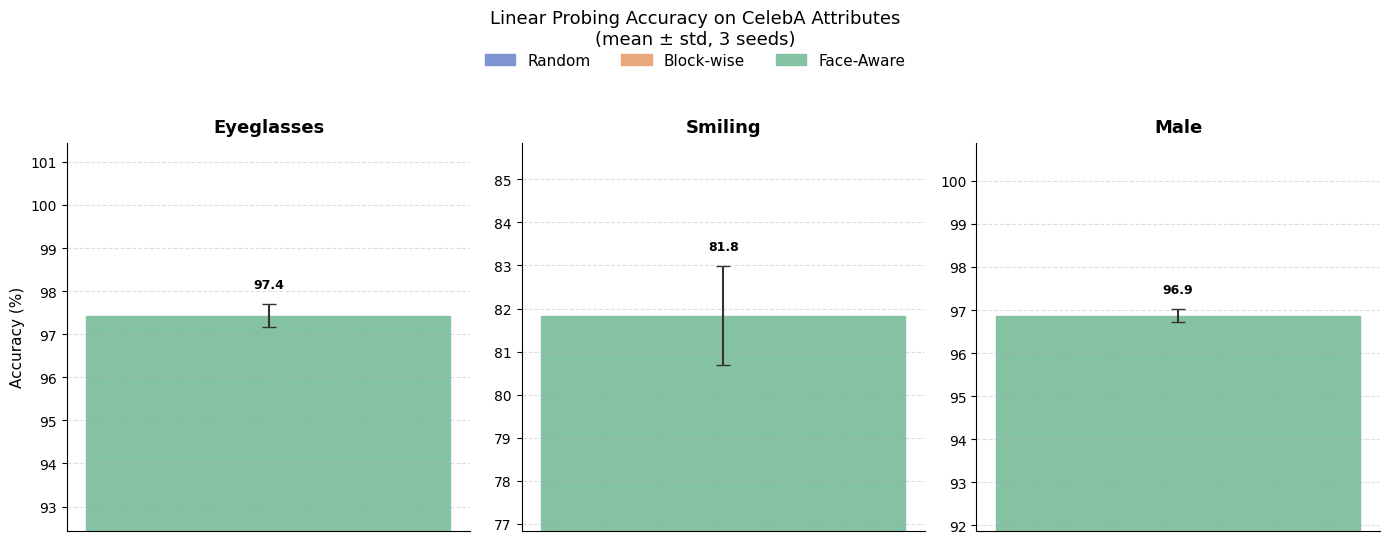

Plot saved → /kaggle/working/linear_probe_results/linear_probe_accuracy.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, len(attr_order), figsize=(14, 5), sharey=False)

COLORS = {
    'Random'    : '#7F95D1',
    'Block-wise': '#E8A87C',
    'Face-Aware': '#85C1A3',
}

for ax, attr in zip(axes, attr_order):
    attr_data = summary[summary['attr'] == attr].set_index('strategy')
    attr_data = attr_data.reindex(strategy_order)
    
    bars = ax.bar(
        attr_data.index,
        attr_data['mean_acc'],
        yerr  = attr_data['std_acc'],
        color = [COLORS[s] for s in attr_data.index],
        capsize= 5,
        error_kw = dict(elinewidth=1.5, ecolor='#333'),
        width = 0.55,
        edgecolor='white', linewidth=1.2,
    )
    
    # Annotate values
    for bar, (_, row) in zip(bars, attr_data.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + row['std_acc'] + 0.3,
            f"{row['mean_acc']:.1f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )
    
    ax.set_title(attr, fontsize=13, fontweight='bold', pad=8)
    ax.set_ylabel('Accuracy (%)' if attr == attr_order[0] else '', fontsize=11)
    ax.set_ylim([
        attr_data['mean_acc'].min() - 5,
        attr_data['mean_acc'].max() + 4
    ])
    ax.set_xticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

# Legend
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()]
fig.legend(
    handles=legend_patches,
    loc='upper center', ncol=3,
    bbox_to_anchor=(0.5, 1.02),
    frameon=False, fontsize=11
)

plt.suptitle('Linear Probing Accuracy on CelebA Attributes\n(mean ± std, 3 seeds)',
             y=1.08, fontsize=13)
plt.tight_layout()

plot_path = OUTPUT_DIR / 'linear_probe_accuracy.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved → {plot_path}")

## Cell 10 — Learning Curves (optional)

In [10]:
# Plot learning curve cho seed=0, tất cả strategy và attribute
# Giúp kiểm tra xem 10 epochs có đủ không

seed0_results = [r for r in all_results if r.get('seed') == 0
                 and r.get('history') is not None]

if seed0_results:
    fig, axes = plt.subplots(1, len(attr_order), figsize=(14, 4), sharey=False)
    
    for ax, attr in zip(axes, attr_order):
        for r in seed0_results:
            if r['attr'] == attr:
                epochs   = [h['epoch']   for h in r['history']]
                val_accs = [h['val_acc'] for h in r['history']]
                ax.plot(epochs, val_accs,
                        color=COLORS[r['strategy']],
                        label=r['strategy'],
                        linewidth=2, marker='o', markersize=4)
        
        ax.set_title(attr, fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Val Accuracy (%)' if attr == attr_order[0] else '')
        ax.grid(linestyle='--', alpha=0.4)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    axes[-1].legend(frameon=False)
    plt.suptitle('Learning Curves (seed=0)', fontsize=13, y=1.02)
    plt.tight_layout()
    
    curve_path = OUTPUT_DIR / 'learning_curves.png'
    plt.savefig(curve_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Curves saved → {curve_path}")
else:
    print("No history data found (results may have been loaded from file).")

No history data found (results may have been loaded from file).


## Cell 11 — Debug: Kiểm tra checkpoint mà không cần chạy full

Chạy cell này **trước** để đảm bảo tất cả checkpoint load được.

In [11]:
print("Checking all checkpoint paths...\n")
all_ok = True

for strategy, seeds_dict in CKPT_PATHS.items():
    for seed, path in seeds_dict.items():
        exists = os.path.exists(path)
        status = "✓" if exists else "✗ NOT FOUND"
        print(f"  [{status}] {strategy} seed={seed}: {path}")
        if not exists:
            all_ok = False

if all_ok:
    print("\nAll checkpoints found! ✓")
    print("\nTrying to load one checkpoint as smoke test...")
    first_strategy = list(CKPT_PATHS.keys())[0]
    first_seed     = list(CKPT_PATHS[first_strategy].keys())[0]
    first_path     = CKPT_PATHS[first_strategy][first_seed]
    
    enc = load_encoder_from_checkpoint(first_path).to(DEVICE)
    _x  = torch.randn(2, 3, 224, 224).to(DEVICE)
    with torch.no_grad():
        out = enc(_x)
    print(f"  Output shape: {tuple(out.shape)}  ← expected (2, *, {ENCODER_CFG['embed_dim']})")
    del enc, _x, out
    print("Checkpoint load OK ✓")
else:
    print("\n[ERROR] Some checkpoints are missing. Fix CKPT_PATHS in Cell 2.")

Checking all checkpoint paths...

  [✓] Face-Aware seed=42: /kaggle/input/datasets/doandangkhoa/mae-checkpoints/faceaware_best.pth
  [✓] Face-Aware seed=123: /kaggle/input/datasets/doandangkhoa/mae-checkpoints/faceaware_best(123).pth
  [✓] Face-Aware seed=2026: /kaggle/input/datasets/doandangkhoa/mae-checkpoints/faceaware_best(2026).pth

All checkpoints found! ✓

Trying to load one checkpoint as smoke test...
  Output shape: (2, 196, 384)  ← expected (2, *, 384)
Checkpoint load OK ✓
